# Iris Classification Model
**Dataset**: Iris (built-in from sklearn)  
**Target**: Species — Setosa / Versicolor / Virginica  
**Algorithm**: Decision Tree Classifier

## Step 1: Load Dataset

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target_names[iris.target], name="Species")

print(f"Shape    : {X.shape[0]} rows, {X.shape[1]} features")
print(f"Features : {list(X.columns)}")
print(f"Classes  : {list(iris.target_names)}")
X.head()

Shape    : 150 rows, 4 features
Features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes  : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Step 2: Class Distribution

In [2]:
y.value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


## Step 3: Train / Test Split (80/20)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 120
Testing  samples : 30


## Step 4: Train Decision Tree Classifier

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


## Step 5: Evaluate the Model

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Confusion Matrix

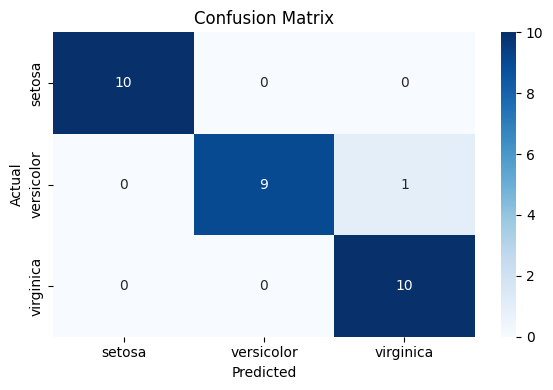

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

classes = list(iris.target_names)
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame(cm, index=classes, columns=classes),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Step 6: Predict a New Sample

In [7]:
sample = pd.DataFrame([{
    "sepal length (cm)": 5.1,
    "sepal width (cm)": 3.5,
    "petal length (cm)": 1.4,
    "petal width (cm)": 0.2
}])

prediction = model.predict(sample)[0]
print(f"Input     : {sample.iloc[0].to_dict()}")
print(f"Predicted : {prediction}")

Input     : {'sepal length (cm)': 5.1, 'sepal width (cm)': 3.5, 'petal length (cm)': 1.4, 'petal width (cm)': 0.2}
Predicted : setosa


In [8]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.9666666666666667
